# Análise de Dados - Aprendizado Federado

Este notebook apresenta a análise dos dados dos experimentos contidos no diretório `Analise/`. Os gráficos gerados seguem o padrão do artigo fornecido, reproduzindo suas análises e adicionando gráficos complementares.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Configurações estéticas para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

/home/nilo/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-xi1k02d_ because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Carregamento e Processamento
Como cada modelo possui 5 experimentos, calculamos a média das métricas entre eles para obter curvas suaves e representativas.

In [2]:
def load_and_average_data(folder_path):
    all_files = glob.glob(os.path.join(folder_path, '*.csv'))
    if not all_files:
        print(f'Nenhum arquivo encontrado em {folder_path}')
        return pd.DataFrame()
    
    df_list = []
    for f in all_files:
        # Lendo o CSV e usando a primeira coluna como índice (Rodadas)
        df = pd.read_csv(f, index_col=0)
        df_list.append(df)
    
    # Concatenar todos os dataframes e calcular a média agrupando pelo índice
    concat_df = pd.concat(df_list)
    mean_df = concat_df.groupby(concat_df.index).mean()
    return mean_df

iid_all_dir = 'iid_all'
iid_leastEnergy_dir = 'iid_leastEnergy'

df_padrao = load_and_average_data(iid_all_dir)
df_leastEnergy = load_and_average_data(iid_leastEnergy_dir)

print(f'Rodadas carregadas Padrão: {len(df_padrao)}')
print(f'Rodadas carregadas LeastEnergy: {len(df_leastEnergy)}')

Rodadas carregadas Padrão: 70
Rodadas carregadas LeastEnergy: 70


### Extração de Métricas Principais
Calculando Energia Total (Wh) e Tempo Acumulado (s).

In [3]:
def extract_metrics(df):
    # Energia total: soma das colunas 'consumption_staX' convertendo Joules para Wh
    consumption_cols = [c for c in df.columns if c.startswith('consumption_sta')]
    energy_total_wh = df[consumption_cols].sum(axis=1) / 3600.0
    
    # Tempo por rodada: tempo máximo gasto entre as estações ativas naquela rodada
    time_cols = [c for c in df.columns if c.startswith('training_time_sta')]
    round_time = df[time_cols].max(axis=1)
    cumulative_time = round_time.cumsum()
    
    acc = df['mean_acc']
    
    return energy_total_wh, cumulative_time, acc

energy_padrao, time_padrao, acc_padrao = extract_metrics(df_padrao)
energy_least, time_least, acc_least = extract_metrics(df_leastEnergy)

## 2. Gráficos do Artigo
Reprodução dos gráficos originais do artigo utilizando os dados compilados.

### 2.1 Comportamento do Consumo de Energia

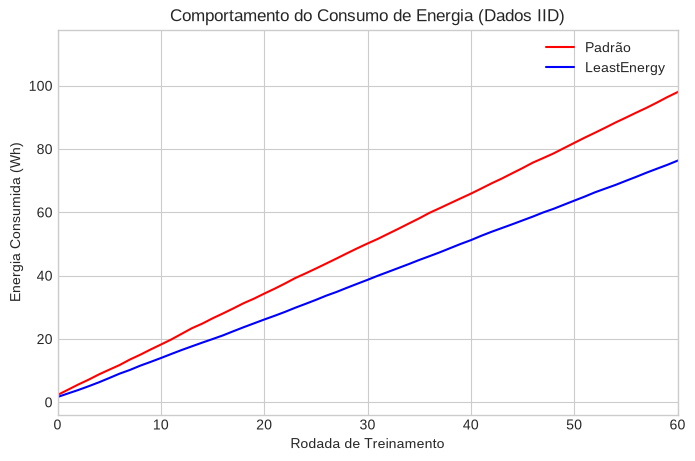

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(energy_padrao.index, energy_padrao.values, label='Padrão', color='red')
plt.plot(energy_least.index, energy_least.values, label='LeastEnergy', color='blue')
plt.xlabel('Rodada de Treinamento')
plt.ylabel('Energia Consumida (Wh)')
plt.title('Comportamento do Consumo de Energia (Dados IID)')
plt.xlim(0, 60)
plt.legend()
plt.grid(True)
plt.show()

### 2.2 Evolução da Acurácia Média vs Tempo

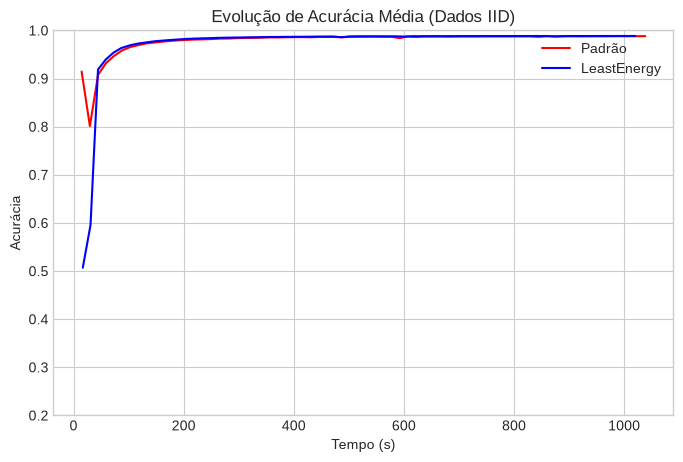

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(time_padrao.values, acc_padrao.values, label='Padrão', color='red')
plt.plot(time_least.values, acc_least.values, label='LeastEnergy', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Acurácia')
plt.title('Evolução de Acurácia Média (Dados IID)')
plt.ylim(0.2, 1.0)
plt.legend()
plt.grid(True)
plt.show()

## 3. Gráficos Complementares
Análises adicionais para aprofundar o entendimento sobre a eficiência da rede.

### 3.1 Acurácia vs Rodada de Treinamento
Apresenta a convergência do modelo em termos do número de comunicações (rodadas globais).

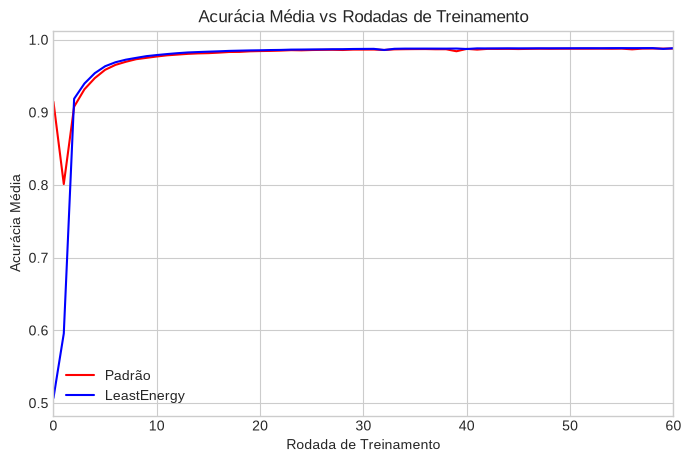

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(acc_padrao.index, acc_padrao.values, label='Padrão', color='red')
plt.plot(acc_least.index, acc_least.values, label='LeastEnergy', color='blue')
plt.xlabel('Rodada de Treinamento')
plt.ylabel('Acurácia Média')
plt.title('Acurácia Média vs Rodadas de Treinamento')
plt.xlim(0, 60)
plt.legend()
plt.grid(True)
plt.show()

### 3.2 Distribuição de Consumo por Dispositivo (Rodada 60)
Mostra a carga de consumo de energia distribuída entre os dispositivos participantes até a última rodada de treinamento.

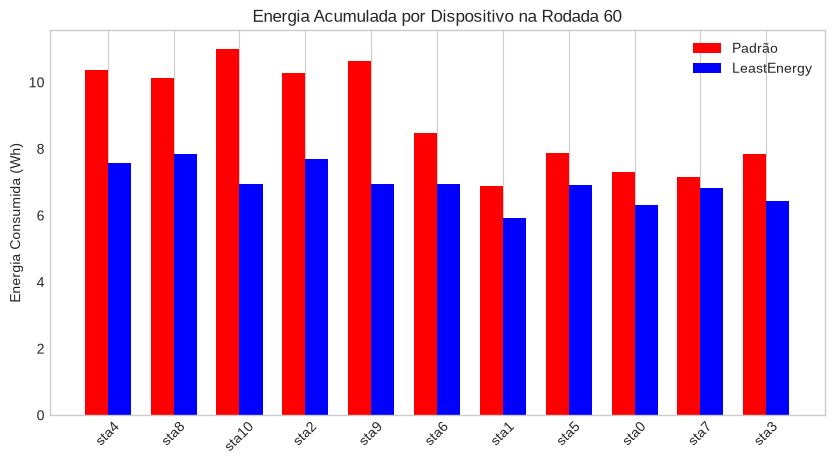

In [7]:
def get_device_energy_at_round(df, target_round=60):
    consumption_cols = [c for c in df.columns if c.startswith('consumption_sta')]
    if target_round in df.index:
        return df.loc[target_round, consumption_cols] / 3600.0
    return None

dev_energy_padrao = get_device_energy_at_round(df_padrao, 60)
dev_energy_least = get_device_energy_at_round(df_leastEnergy, 60)

if dev_energy_padrao is not None and dev_energy_least is not None:
    labels = [c.replace('consumption_', '') for c in dev_energy_padrao.index]
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, dev_energy_padrao.values, width, label='Padrão', color='red')
    ax.bar(x + width/2, dev_energy_least.values, width, label='LeastEnergy', color='blue')
    
    ax.set_ylabel('Energia Consumida (Wh)')
    ax.set_title('Energia Acumulada por Dispositivo na Rodada 60')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    plt.grid(axis='y')
    plt.show()

### 3.3 Número de Dispositivos Ativos por Rodada
Permite observar as políticas de seleção de clientes ao longo do tempo. (Média calculada sobre os 5 experimentos).

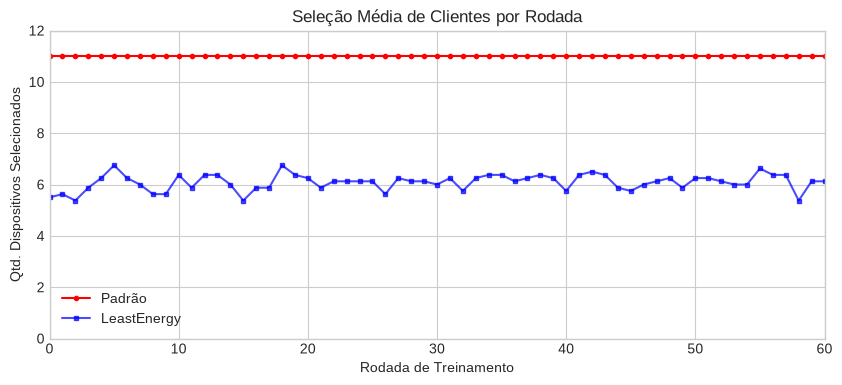

In [8]:
def count_active_devices_avg(folder_path):
    all_files = glob.glob(os.path.join(folder_path, '*.csv'))
    counts = []
    for f in all_files:
        df = pd.read_csv(f, index_col=0)
        time_cols = [c for c in df.columns if c.startswith('training_time_sta')]
        counts.append(df[time_cols].notna().sum(axis=1))
    if counts:
        return pd.concat(counts, axis=1).mean(axis=1)
    return pd.Series()

active_padrao = count_active_devices_avg(iid_all_dir)
active_least = count_active_devices_avg(iid_leastEnergy_dir)

plt.figure(figsize=(10, 4))
plt.plot(active_padrao.index, active_padrao.values, label='Padrão', color='red', marker='o', markersize=3)
plt.plot(active_least.index, active_least.values, label='LeastEnergy', color='blue', marker='s', markersize=3, alpha=0.7)
plt.xlabel('Rodada de Treinamento')
plt.ylabel('Qtd. Dispositivos Selecionados')
plt.title('Seleção Média de Clientes por Rodada')
plt.xlim(0, 60)
plt.ylim(0, 12)
plt.legend()
plt.grid(True)
plt.show()

### 3.4 Tempo Médio de Treinamento por Rodada
Evolução do tempo que cada rodada de treinamento exige para concluir, mostrando a eficiência temporal da alocação de recursos.

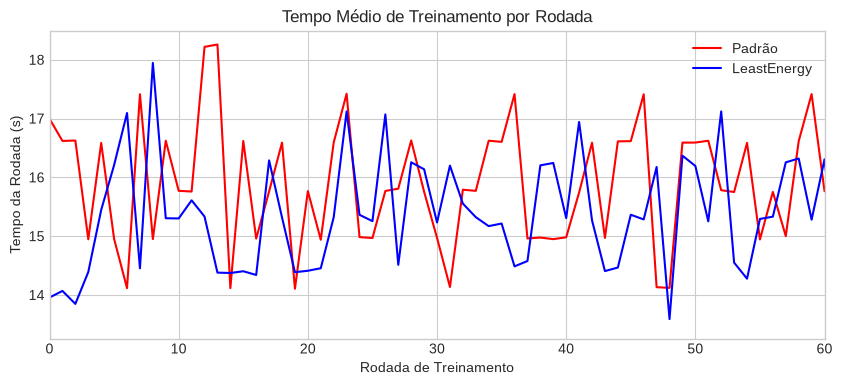

In [9]:
def get_round_time_avg(folder_path):
    all_files = glob.glob(os.path.join(folder_path, '*.csv'))
    times = []
    for f in all_files:
        df = pd.read_csv(f, index_col=0)
        time_cols = [c for c in df.columns if c.startswith('training_time_sta')]
        times.append(df[time_cols].max(axis=1))
    if times:
        return pd.concat(times, axis=1).mean(axis=1)
    return pd.Series()

round_time_padrao = get_round_time_avg(iid_all_dir)
round_time_least = get_round_time_avg(iid_leastEnergy_dir)

plt.figure(figsize=(10, 4))
plt.plot(round_time_padrao.index, round_time_padrao.values, label='Padrão', color='red')
plt.plot(round_time_least.index, round_time_least.values, label='LeastEnergy', color='blue')
plt.xlabel('Rodada de Treinamento')
plt.ylabel('Tempo da Rodada (s)')
plt.title('Tempo Médio de Treinamento por Rodada')
plt.xlim(0, 60)
plt.legend()
plt.grid(True)
plt.show()